In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.metrics import mean_squared_error


In [2]:
health_data = pd.read_csv("cbc_demo_merged_1999_2018.csv")

In [3]:
health_data.shape
health_data.head()
health_data.info()
health_data.describe()

<class 'pandas.DataFrame'>
RangeIndex: 92988 entries, 0 to 92987
Columns: 220 entries, SEQN to DMDHSEDZ
dtypes: float64(207), int64(9), str(4)
memory usage: 156.1 MB


,SEQN,LBXWBCSI,LBXLYPCT,LBXMOPCT,LBXNEPCT,LBXEOPCT,LBXBAPCT,LBDLYMNO,LBDMONO,LBDNENO,...,DMDBORN4,AIALANGA,DMDHHSZA,DMDHHSZB,DMDHHSZE,DMDHRBR4,DMDHRAGZ,DMDHREDZ,DMDHRMAZ,DMDHSEDZ
count,92988.000000,82923.000000,82744.000000,82744.000000,82744.000000,82744.000000,82744.000000,82741.000000,82741.000000,82741.000000,...,35909.000000,23010.000000,35909.000000,35909.000000,35909.000000,26636.000000,8366.000000,7973.000000,8200.000000,4357.000000
mean,51172.066578,7.307269,33.616705,8.039510,54.659993,3.035912,0.701780,2.408662,0.570412,4.063330,...,1.250884,1.119991,0.484837,0.992648,0.433178,1.421535,2.888597,2.051298,1.473415,2.101905
std,29744.085046,2.743337,10.715035,2.360588,11.737409,2.438622,0.535253,1.773500,0.208942,1.788205,...,1.745351,0.369281,0.780974,1.169852,0.723554,2.919063,0.805552,0.655558,0.720495,0.687811
min,1.000000,1.400000,2.600000,0.600000,0.800000,0.000000,0.000000,0.200000,0.000000,0.100000,...,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,25334.750000,5.700000,26.300000,6.500000,47.600000,1.500000,0.400000,1.800000,0.400000,2.800000,...,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,2.000000,2.000000,1.000000,2.000000
50%,50814.500000,7.000000,32.400000,7.800000,55.700000,2.400000,0.600000,2.200000,0.500000,3.800000,...,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,3.000000,2.000000,1.000000,2.000000
75%,77569.250000,8.500000,39.800000,9.300000,62.800000,3.800000,0.900000,2.800000,0.700000,5.000000,...,1.000000,1.000000,1.000000,2.000000,1.000000,2.000000,4.000000,2.000000,2.000000,3.000000
max,102956.000000,400.000000,94.500000,66.900000,96.600000,57.200000,35.400000,358.800000,10.200000,83.100000,...,99.000000,3.000000,3.000000,4.000000,3.000000,99.000000,4.000000,3.000000,3.000000,3.000000


In [4]:
health_data = pd.read_csv("cbc_demo_merged_1999_2018.csv")

analysis_data = health_data[
    [
        "LBXHGB",      # Hemoglobin
        "RIDAGEYR",    # Age
        "RIAGENDR",    # Sex
        "RIDRETH1",    # Race
        "LBXHCT",      # Hematocrit
        "LBXMCVSI",    # Mean corpuscular volume
        "LBXMCHSI",    # Mean corpuscular hemoglobin
        "LBXRDW",      # Red cell distribution width
        "LBXWBCSI"     # White blood cell count
    ]
].copy()

analysis_data = analysis_data.rename(columns={
    "LBXHGB": "hemoglobin",
    "RIDAGEYR": "age",
    "RIAGENDR": "sex",
    "RIDRETH1": "race",
    "LBXHCT": "hematocrit",
    "LBXMCVSI": "mcv",
    "LBXMCHSI": "mch",
    "LBXRDW": "rdw",
    "LBXWBCSI": "wbc"
})


In [5]:
analysis_data["sex"] = analysis_data["sex"].astype("category")
analysis_data["race"] = analysis_data["race"].astype("category")

analysis_data_clean = analysis_data.dropna()
analysis_data_clean.shape


(82923, 9)

In [7]:
X = analysis_data_clean.drop(columns=["hemoglobin"])
y = analysis_data_clean["hemoglobin"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)


In [8]:
X_train_enc = pd.get_dummies(X_train, drop_first=True)
X_test_enc = pd.get_dummies(X_test, drop_first=True)

# Ensure alignment
X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

# EXPLORATORY ANALYSIS

In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_enc)
X_test_scaled = scaler.transform(X_test_enc)

lasso = LassoCV(cv=5, random_state=42)
lasso.fit(X_train_scaled, y_train)

lasso_coefs = pd.Series(lasso.coef_, index=X_train_enc.columns)
selected_vars = lasso_coefs[lasso_coefs != 0].index.tolist()

selected_vars


['age',
 'hematocrit',
 'mcv',
 'mch',
 'rdw',
 'wbc',
 'sex_2',
 'race_3',
 'race_4',
 'race_5']

In [10]:
#full model
full_model = LinearRegression()
full_model.fit(X_train_enc, y_train)

full_mse = mean_squared_error(
    y_test, full_model.predict(X_test_enc)
)

In [11]:
X_train_red = X_train_enc[selected_vars]
X_test_red = X_test_enc[selected_vars]

reduced_model = LinearRegression()
reduced_model.fit(X_train_red, y_train)

reduced_mse = mean_squared_error(
    y_test, reduced_model.predict(X_test_red)
)

In [12]:
observed_difference = reduced_mse - full_mse
full_mse, reduced_mse, observed_difference


(0.009755348796494322, 0.009755351033870022, 2.2373756996402205e-09)

In [13]:
n_perm = 1000
perm_diffs = []

for _ in range(n_perm):
    y_perm = np.random.permutation(y_train)

    full_model.fit(X_train_enc, y_perm)
    reduced_model.fit(X_train_red, y_perm)

    full_mse_p = mean_squared_error(
        y_test, full_model.predict(X_test_enc)
    )
    reduced_mse_p = mean_squared_error(
        y_test, reduced_model.predict(X_test_red)
    )

    perm_diffs.append(reduced_mse_p - full_mse_p)

In [14]:
p_value = np.mean(
    np.array(perm_diffs) >= observed_difference
)
p_value

np.float64(0.426)

In [15]:
boot_mse = []

for _ in range(1000):
    idx = np.random.choice(len(X_train_enc), size=len(X_train_enc), replace=True)
    Xb, yb = X_train_enc.iloc[idx], y_train.iloc[idx]

    full_model.fit(Xb, yb)
    preds = full_model.predict(X_test_enc)
    boot_mse.append(mean_squared_error(y_test, preds))

np.quantile(boot_mse, [0.025, 0.975])

array([0.00968129, 0.01023662])

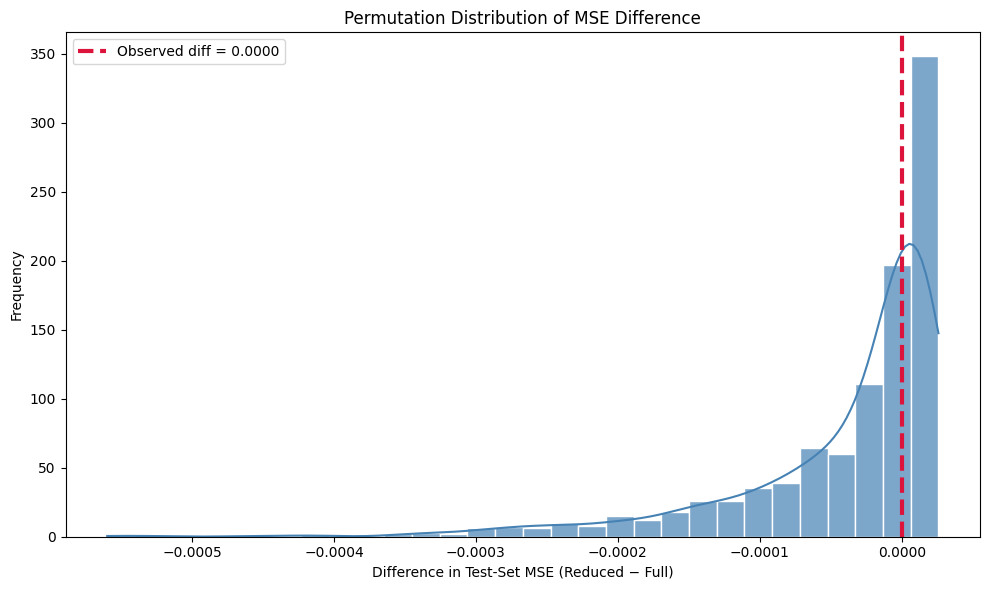

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Convert to array for convenience
perm_diffs = np.array(perm_diffs)

plt.figure(figsize=(10, 6))

# Histogram of permutation differences
sns.histplot(
    perm_diffs,
    bins=30,
    kde=True,
    color="steelblue",
    edgecolor="white",
    alpha=0.7
)

# Add observed statistic
plt.axvline(
    observed_difference,
    color="crimson",
    linestyle="--",
    linewidth=3,
    label=f"Observed diff = {observed_difference:.4f}"
)

# Labels and title
plt.xlabel("Difference in Test-Set MSE (Reduced − Full)")
plt.ylabel("Frequency")
plt.title("Permutation Distribution of MSE Difference")

plt.legend()
plt.tight_layout()
plt.show()


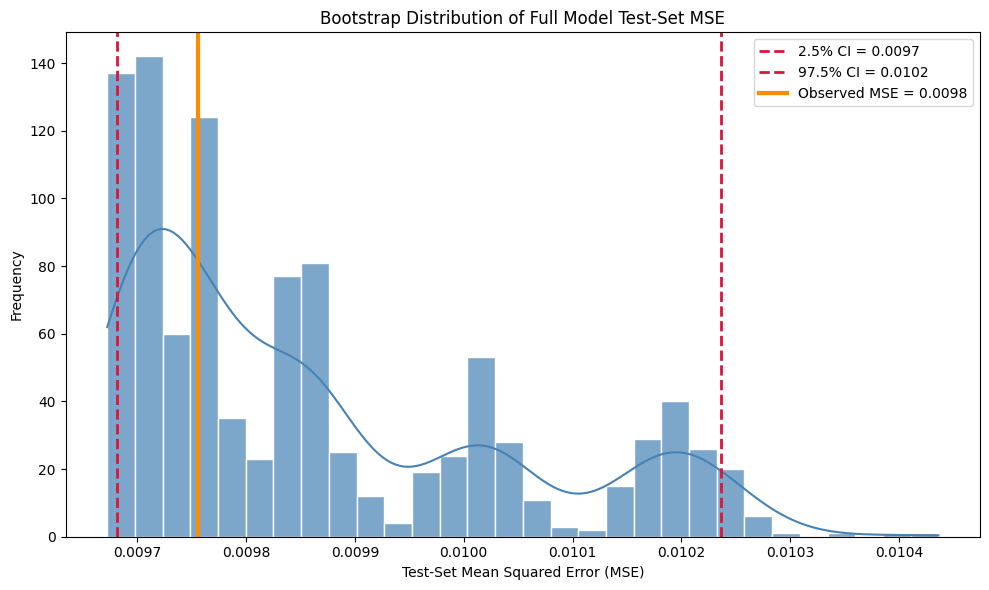

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Convert list to array
boot_mse = np.array(boot_mse)

# Compute 95% bootstrap CI
lower_ci, upper_ci = np.quantile(boot_mse, [0.025, 0.975])

plt.figure(figsize=(10, 6))

# Histogram of bootstrap MSE values
sns.histplot(
    boot_mse,
    bins=30,
    kde=True,
    color="steelblue",
    edgecolor="white",
    alpha=0.7
)

# Confidence interval lines
plt.axvline(
    lower_ci,
    color="crimson",
    linestyle="--",
    linewidth=2,
    label=f"2.5% CI = {lower_ci:.4f}"
)

plt.axvline(
    upper_ci,
    color="crimson",
    linestyle="--",
    linewidth=2,
    label=f"97.5% CI = {upper_ci:.4f}"
)

# Observed test-set MSE
plt.axvline(
    full_mse,
    color="darkorange",
    linewidth=3,
    label=f"Observed MSE = {full_mse:.4f}"
)

# Labels and title
plt.xlabel("Test-Set Mean Squared Error (MSE)")
plt.ylabel("Frequency")
plt.title("Bootstrap Distribution of Full Model Test-Set MSE")

plt.legend()
plt.tight_layout()
plt.show()
